In [2]:
# Install all dependencies
%pip install matplotlib scikit-image numpy Pillow

Note: you may need to restart the kernel to use updated packages.


In [21]:
# Packages
import os
import glob
import matplotlib.pyplot as plt
from skimage.color import rgb2hsv
import numpy as np
from PIL import Image
import cv2 as cv

In [22]:
# Load the datasets

# change path according to where u put the folder
path = "flowers_dataset" 
images_path = glob.glob(os.path.join(path, "*.jpg"))

print("Number of images:", len(images_path))


Number of images: 10


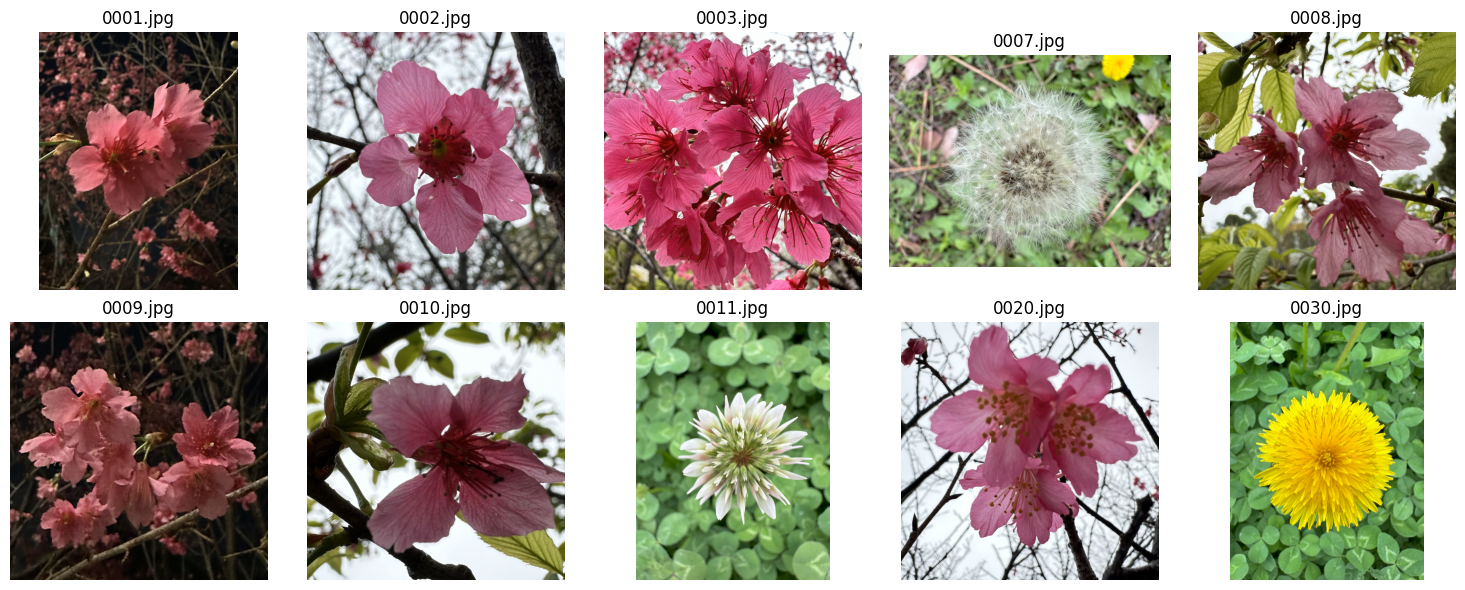

In [23]:
# Show all images first

plt.figure(figsize=(15, 6)) 

for i, file in enumerate(images_path):
    img = Image.open(file)
    plt.subplot(2, 5, i+1)  
    plt.imshow(img)
    plt.axis("off")
    plt.title(os.path.basename(file))

plt.tight_layout()
plt.show()

In [24]:
# Open them as PIL images
images = [Image.open(file) for file in images_path]

In [25]:
# Function that reshapes the images to (100,100,3)
def image_reshape(img):
    img = img.convert("RGB")
    img = img.resize((100, 100))
    return np.array(img)

In [26]:
# Reshape all
reshaped_img = [image_reshape(img) for img in images]
print("Shape of first reshaped image:", reshaped_img[0].shape)

Shape of first reshaped image: (100, 100, 3)


In [27]:
# Save all of the images in another directory

output_path = "reshaped_dataset"
os.makedirs(output_path, exist_ok=True)

for i, arr in enumerate(reshaped_img):
    img = Image.fromarray(arr)  # convert NumPy array back to PIL
    save_path = os.path.join(output_path, f"flower_{i+1}.jpg")
    img.save(save_path, "JPEG")

print(f"Saved {len(reshaped_img)} images to '{output_path}'")

Saved 10 images to 'reshaped_dataset'


In [28]:
# Separate RGB channels

img_data = np.stack(reshaped_img)

red = img_data[:,:,:,0].ravel()
green = img_data[:,:,:,1].ravel()
blue = img_data[:,:,:,2].ravel()

In [29]:
# Normalize img_data
rgb_norm = img_data / 255.0
hsv = rgb2hsv(rgb_norm)

In [30]:
# Separate hues, saturation, and intensities

hues        = hsv[:,:,:,0].ravel()       
saturations = hsv[:,:,:,1].ravel()        
intensities = hsv[:,:,:,2].ravel()

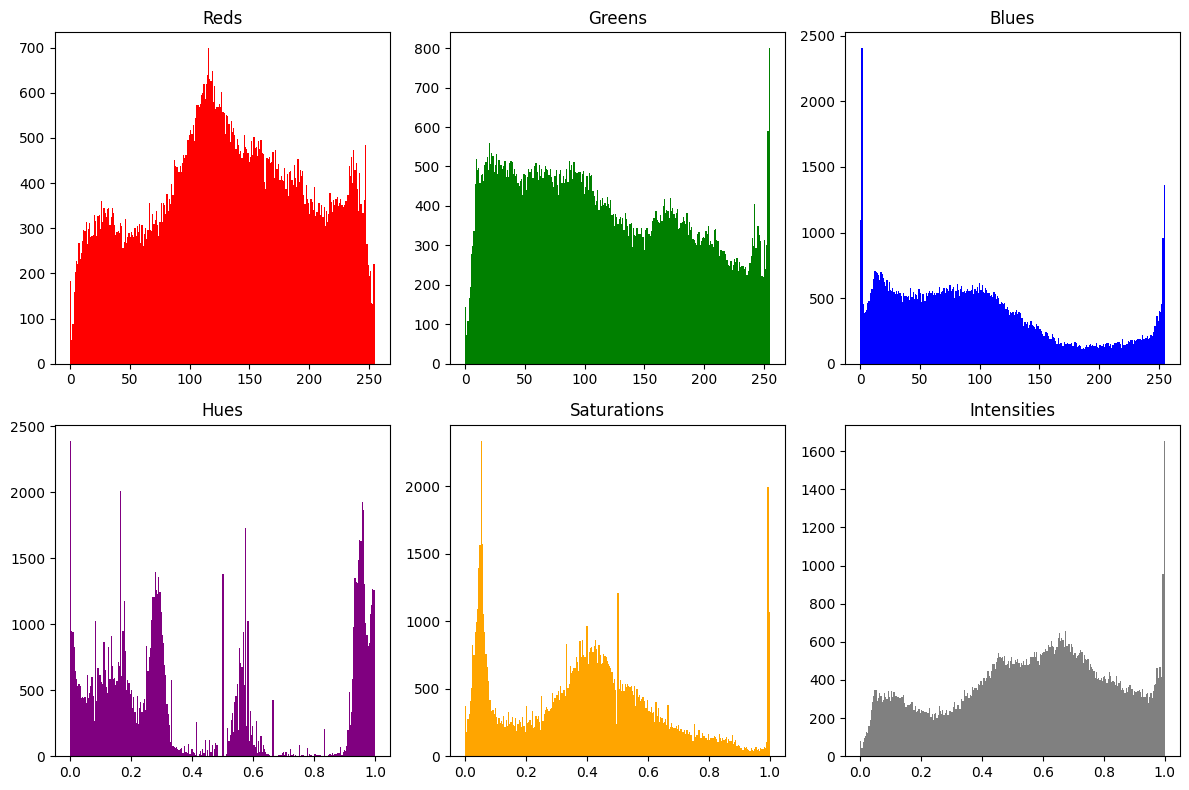

In [13]:
#Plot the histogram

plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.hist(red, bins=256, color='red')
plt.title("Reds")

plt.subplot(2,3,2)
plt.hist(green, bins=256, color='green')
plt.title("Greens")

plt.subplot(2,3,3)
plt.hist(blue, bins=256, color='blue')
plt.title("Blues")

plt.subplot(2,3,4)
plt.hist(hues, bins=256, color='purple')
plt.title("Hues")

plt.subplot(2,3,5)
plt.hist(saturations, bins=256, color='orange')
plt.title("Saturations")

plt.subplot(2,3,6)
plt.hist(intensities, bins=256, color='gray')
plt.title("Intensities")

plt.tight_layout()
plt.show()


Guide Questions:
- In the RGB space, which channel is most likely to be observed for all images?


- In the HSV space, which top three hues are most likely to be observed for all images?

## [Data Cleaning] Develop a function that attains the following activities:
- Remove all images that are taken during the night.
- Remove all images that are not pink flowers.

In [ ]:
# Function that detects if night time
# Returns images took during day or noon
def removeNight(img):
    rgb_norm = img / 255.0
    hsv = rgb2hsv(rgb_norm)
    hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
    brightness = hsv[:, :, 2].mean()
    if brightness > 80:         # Threshold value of 80 change if need.
        return img

# 70 was the initial threshold value taken from the Medium article.
# It was then adjusted based on the observed brightness of the images identified
# taken during the night, thus 80 was selected.
    
# https://medium.com/@DIYCoding/classifying-day-evening-and-night-from-videos-using-opencv-5789f7f41956    


# Function that removes non pink flowers
# Returns images that are pink
def removeNonPink(img):
    img = img.convert("RGB")
    img = img.resize((100, 100))
    return np.array(img)

In [57]:
day_images = [removeNight(img) for img in reshaped_img]

for img in day_images:
    print(img.shape)

plt.figure(figsize=(15, 6)) 
day_images = [np.array(img) for img in day_images]
for i, img in enumerate(day_images):
    plt.subplot(2, 5, i+1)  
    plt.imshow(img)
    plt.axis("off")
    #plt.title(os.path.basename(file))

plt.tight_layout()
plt.show()

AttributeError: 'NoneType' object has no attribute 'shape'